# Homework 1: Solving an ODE

Given an ordinary differential equation:

$$
\frac{d}{dt}x(t) = 1 - x(t)
$$

with initial condition $x(t=0)=0.0$

## Part 1: Julia's ODE solver

Please **solve** the ODE using `OrdinaryDiffEq.jl` (optionally `ModelingToolkit.jl`) for $t \in [0, 5]$ and **plot** the time series. **Compare** it to the analytical solution *in one plot*.

## Part 2: The forward Euler method

Please **try** a range of time steps (e.g. from 0.1 to 1.5) to **solve** the ODE using the (home-made) forward Euler method for $t \in [0.0, 5.0]$, **plot** the time series, and **compare** them to the analytical solution *in one plot*. In which way are dts related to accuracy?

**About the forward Euler method**

We plot the trajectory as a straight line locally. In each step, the next state variables ($\vec{u}_{n+1}$) is accumulated by the time step (dt) multiplied the derivative ( slope) at the current state ($\vec{u}_{n}$):

$$
\vec{u}_{n+1} = \vec{u}_{n} + dt \cdot f(\vec{u}_{n}, t_{n})
$$

The ODE model. Exponential decay in this example

In [1]:
function model(u, p, t)
    return 1 .- u[1]
end

model (generic function with 1 method)

Forward Euler method

In [2]:
euler(model, u, p, t, dt) = u .+ dt .* model(u, p, t)

euler (generic function with 1 method)

The home-grown ODE solver

In [3]:
function mysolve(model, u0, tspan, p; dt=0.1, method=euler)
    # Time points
    ts = tspan[begin]:dt:tspan[end]
    # States at those time points
    us = zeros(length(ts), length(u0))
    # Initial conditions
    us[1, :] .= u0
    # Iterations in a for loop
    for i in 1:length(ts)-1
        us[i+1, :] .= method(model, us[i, :], p, ts[i], dt)
    end
    # Return results
    return (t = ts, u = us)
end

mysolve (generic function with 1 method)

Time span, parameter(s), and initial condition(s)

In [4]:
tspan = (0.0, 5.0)
p = nothing
u0 = 0.0

0.0

Solve the problem

In [5]:
sol = mysolve(model, u0, tspan, p, dt=1.0, method=euler)

(t = 0.0:1.0:5.0, u = [0.0; 1.0; … ; 1.0; 1.0;;])

Analytical solution

In [6]:
analytical(t) = 1 - exp(-t)

analytical (generic function with 1 method)

Visualization

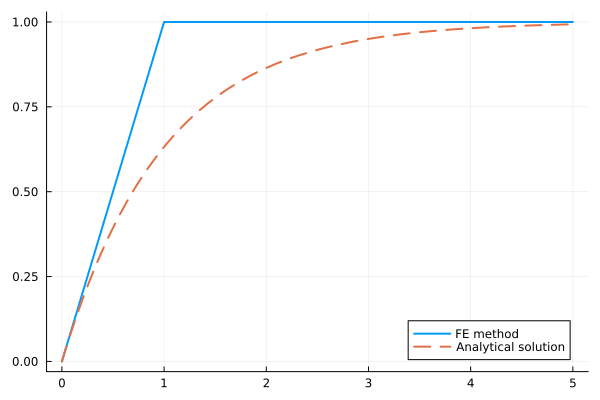

In [7]:
using Plots
Plots.default(linewidth=2)

plot(sol.t, sol.u, label="FE method")
plot!(analytical, sol.t[begin], sol.t[end], label = "Analytical solution", linestyle=:dash)

## Part 3: The RK4 method

1. Please **try** a range of dts to **solve** the ODE using the (home-grown) fourth order Runge-Kutta ([RK4](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods)) method for $t \in [0.0, 5.0]$, **plot** the time series, and **compare** them to the analytical solution *in one plot*. In which way are dts related to accuracy?
2. Compared to the forward Euler method, which one is more accurate for the same `dt`? Please make a visual comparison by plotting the analytical solution, Euler's solution, and RK4's solution together.

**About the RK4 method**

We use 4 additional intermediate steps to eliminate some of the nonlinear (higher order) errors in the integration. In each iteration, the next state $\vec{u}_{n+1}$ is:

$$
\begin{align}
k_1 &= dt \cdot f(\vec{u}_{n}, t_n)  \\
k_2 &= dt \cdot f(\vec{u}_{n} + 0.5k_1, t_n + 0.5dt)  \\
k_3 &= dt \cdot f(\vec{u}_{n} + 0.5k_2, t_n + 0.5dt)  \\
k_4 &= dt \cdot f(\vec{u}_{n} + k_3, t_n + dt)  \\
\vec{u}_{n+1} &= \vec{u}_{n} + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)
\end{align}
$$

Hint: you can replace the Euler method with the RK4 one to reuse the `mysolve()` function.

```julia
# Forward Euler stepper
euler(model, u, p, t, dt) = u .+ dt .* model(u, p, t)
# Your RK4 stepper
function rk4(model, u, p, t, dt)
    # calculate k1, k2, k3, and k4
    next = u .+ (k1 .+ 2k2 .+ 2k3 .+ k4) ./ 6
    return next
end

sol = mysolve(model, u0, tspan, p, dt=1.0, method=rk4)
```

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*